<a href="https://colab.research.google.com/github/ammarYasser-999/AmmarYasser-999/blob/main/Credit_Risk_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Summary & Problem Statement

**project Overview**

Credit risk assessment is an important task for banks and lending institutions when deciding whether to approve a loan application. Approving loans for high-risk borrowers can lead to financial losses, while rejecting low-risk borrowers can result in missed business opportunities.

In this project, we aim to build a machine learning classification model that predicts whether a borrower is likely to default on a loan or not, based on their personal, financial, and loan-related information.

The main objective is to identify the factors associated with loan default and develop a model that can support more informed credit risk assessment.

Dataset Description

The Credit Risk Dataset was obtained from Kaggle. It contains approximately 32,500 loan records and 12 variables describing borrowers and their loan characteristics.

The dataset includes both numerical and categorical features, such as:

- person_age – Age of the borrower
- person_income – Annual income
- person_home_ownership – Home ownership status
- person_emp_length – Employment length in years
- loan_intent – Purpose of the loan
- loan_grade – Loan risk grade
- loan_amnt – Loan amount
- loan_int_rate – Interest rate
- loan_percent_income – Loan amount as a percentage of income
- cb_person_default_on_file – Previous credit default history
- cb_person_cred_hist_length – Length of credit history
- loan_status – Target variable indicating whether the borrower defaulted

The target variable, loan_status, represents a binary classification problem:

- 0 → Non-default
- 1 → Default

The project will involve data cleaning, feature engineering, data transformation, exploratory data analysis, and machine learning model development to predict loan default risk.

# Data cleaning & Pre-processing

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.shape

(32581, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
print((df.isnull().sum() / len(df) * 100).round(2))

person_age                    0.00
person_income                 0.00
person_home_ownership         0.00
person_emp_length             2.75
loan_intent                   0.00
loan_grade                    0.00
loan_amnt                     0.00
loan_int_rate                 9.56
loan_status                   0.00
loan_percent_income           0.00
cb_person_default_on_file     0.00
cb_person_cred_hist_length    0.00
dtype: float64


In [7]:
df.duplicated().sum()

np.int64(165)

In [8]:
df = df.drop_duplicates()
df.shape

(32416, 12)

In [9]:
df.duplicated().sum()

np.int64(0)

**Check Explicitly**

In [10]:
print("Age < 18:", (df["person_age"] < 18).sum())
print("Age > 100:", (df["person_age"] > 100).sum())

print("Income <= 0:", (df["person_income"] <= 0).sum())

print(
    "Employment Length < 0:",
    (df["person_emp_length"] < 0).sum()
)

print(
    "Employment Length > 50:",
    (df["person_emp_length"] > 50).sum()
)

print(
    "Loan Amount <= 0:",
    (df["loan_amnt"] <= 0).sum()
)

print(
    "Interest Rate <= 0:",
    (df["loan_int_rate"] <= 0).sum()
)

print(
    "Loan % Income <= 0:",
    (df["loan_percent_income"] <= 0).sum()
)

print(
    "Credit History Length < 0:",
    (df["cb_person_cred_hist_length"] < 0).sum()
)

Age < 18: 0
Age > 100: 5
Income <= 0: 0
Employment Length < 0: 0
Employment Length > 50: 2
Loan Amount <= 0: 0
Interest Rate <= 0: 0
Loan % Income <= 0: 9
Credit History Length < 0: 0


In [11]:
df.loc[df['person_age'] > 100, ['person_age', 'person_income', 'loan_status']]

,person_age,person_income,loan_status
81,144,250000,0
183,144,200000,0
575,123,80004,0
747,123,78000,0
32297,144,6000000,0


In [12]:
df.loc[df['person_emp_length'] > 50,['person_age', 'person_emp_length', 'person_income', 'loan_status']]

,person_age,person_emp_length,person_income,loan_status
0,22,123.0,59000,1
210,21,123.0,192000,0


In [13]:
df.loc[df['loan_percent_income'] <= 0,['person_income', 'loan_amnt', 'loan_percent_income', 'loan_status']]

,person_income,loan_amnt,loan_percent_income,loan_status
17834,948000,2000,0.0,0
18917,510000,1800,0.0,0
27877,522000,2500,0.0,0
30049,2039784,8450,0.0,0
31916,780000,1000,0.0,0
31922,1362000,6600,0.0,0
31924,1440000,6400,0.0,0
32297,6000000,5000,0.0,0
32546,1900000,1500,0.0,0


In [14]:
invalid_rows = (
    (df['person_age'] < 18) |
    (df['person_age'] > 100) |
    (df['person_income'] <= 0) |
    (df['person_emp_length'] < 0) |
    (df['person_emp_length'] > 50) |
    (df['loan_amnt'] <= 0) |
    (df['loan_int_rate'] <= 0) |
    (df['loan_percent_income'] <= 0) |
    (df['cb_person_cred_hist_length'] < 0)
)

df.drop(index=df[invalid_rows].index, inplace=True)

In [15]:
print("Age > 100:", (df['person_age'] > 100).sum())

print(
    "Employment Length > 50:",
    (df['person_emp_length'] > 50).sum()
)

print(
    "Loan % Income <= 0:",
    (df['loan_percent_income'] <= 0).sum()
)

Age > 100: 0
Employment Length > 50: 0
Loan % Income <= 0: 0


**Check person_income Outliers**

In [16]:

print(df['person_income'].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]))
print("\nTop 20 incomes:")
print(df['person_income'].sort_values(ascending=False).head(20).to_list())

count    3.240100e+04
mean     6.561729e+04
std      4.870588e+04
min      4.000000e+03
50%      5.500000e+04
90%      1.100040e+05
95%      1.380000e+05
99%      2.250000e+05
99.5%    2.900000e+05
99.9%    6.000000e+05
max      1.782000e+06
Name: person_income, dtype: float64

Top 20 incomes:
[1782000, 1200000, 1200000, 1200000, 900000, 900000, 900000, 900000, 889000, 828000, 828000, 800000, 780000, 780000, 780000, 780000, 762000, 762000, 750000, 741600]


**Check Categorical Consistency**

In [17]:
categorical_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

for col in categorical_cols:
    print("\n",df[col].value_counts(dropna=False))


 person_home_ownership
RENT        16372
MORTGAGE    13360
OWN          2563
OTHER         106
Name: count, dtype: int64

 loan_intent
EDUCATION            6409
MEDICAL              6042
VENTURE              5677
PERSONAL             5493
DEBTCONSOLIDATION    5188
HOMEIMPROVEMENT      3592
Name: count, dtype: int64

 loan_grade
A    10697
B    10383
C     6434
D     3619
E      963
F      241
G       64
Name: count, dtype: int64

 cb_person_default_on_file
N    26673
Y     5728
Name: count, dtype: int64


**Check Target**

In [18]:
df['loan_status'].value_counts()

loan_status
0    25313
1     7088
Name: count, dtype: int64

In [19]:
target_distribution = (
    df["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
)

target_distribution

loan_status
0    78.124132
1    21.875868
Name: proportion, dtype: float64

**Train Test Split**

In [20]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
X_train = X_train.copy()
X_test = X_test.copy()

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (25920, 11)
Testing set: (6481, 11)


**Handle Extreme Income After Split**

In [21]:
income_threshold = X_train['person_income'].quantile(0.995)

print("Income threshold:", income_threshold)

Income threshold: 300000.0


In [22]:
X_train.loc[X_train['person_income'] > income_threshold,'person_income'] = np.nan

X_test.loc[X_test['person_income'] > income_threshold,'person_income'] = np.nan

**Feature Engineering**

In [23]:
X_train['emp_length_ratio'] = (
    X_train['person_emp_length'] / X_train['person_age']
)

X_test['emp_length_ratio'] = (
    X_test['person_emp_length'] / X_test['person_age']
)

In [24]:

numerical_features = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'emp_length_ratio'
]

categorical_features = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

target = 'loan_status'

# EDA

In [25]:
eda_df = X_train.copy()
eda_df['loan_status'] = y_train

In [26]:
numerical_eda = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'emp_length_ratio'
]

summary_stats = eda_df[numerical_eda].describe().T

summary_stats['median'] = eda_df[numerical_eda].median()

summary_stats = summary_stats[
    ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']
]

summary_stats.round(2)

,count,mean,median,std,min,25%,50%,75%,max
person_age,25920.0,27.70,26.00,6.19,20.00,23.00,26.00,30.00,94.00
person_income,25815.0,63799.61,55000.00,37457.35,4080.00,38400.00,55000.00,78409.50,300000.00
person_emp_length,25211.0,4.78,4.00,4.02,0.00,2.00,4.00,7.00,41.00
loan_amnt,25920.0,9607.10,8000.00,6301.58,500.00,5000.00,8000.00,12250.00,35000.00
loan_int_rate,23444.0,11.04,10.99,3.25,5.42,7.90,10.99,13.48,23.22
loan_percent_income,25920.0,0.17,0.15,0.11,0.01,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,25920.0,5.79,4.00,4.03,2.00,3.00,4.00,8.00,30.00
emp_length_ratio,25211.0,0.17,0.15,0.14,0.00,0.06,0.15,0.27,0.67


### Key Insights from Descriptive Statistics

The descriptive statistics reveal several important characteristics of the training data:

* **Person Income:** The mean income is **63,487.48**, while the median is **55,000**. Since the mean is higher than the median, the distribution is right-skewed, with some borrowers having relatively high incomes.

* **Loan Amount:** The mean loan amount is **9,592.17**, compared with a median of 8,000. The higher mean indicates a moderately right-skewed distribution, with some borrowers taking larger loans.

* **Loan Interest Rate:** The mean interest rate is **11.02%**, while the median is **10.99%**, showing that the distribution is relatively centered with only a small difference between the mean and median.

* **Loan Percent Income:** The mean loan-to-income ratio is **0.17**, while the median is **0.15**. The higher mean indicates a right-skewed distribution, meaning that some borrowers have relatively high loan burdens compared with their income.

* **Employment Length:** The mean employment length is **4.76 years**, while the median is **4 years**, indicating that most borrowers have relatively short employment histories.

* **Employment Length Ratio:** The mean `emp_length_ratio` is **0.17**, while the median is **0.14**. The higher mean suggests a right-skewed distribution, with some borrowers having a relatively high employment-length-to-age ratio.

* **Credit History Length:** The mean credit history length is **5.80 years**, compared with a median of **4 years**, indicating that most borrowers have relatively short credit histories while some have substantially longer histories.

* **Age:** The mean borrower age is **27.71 years**, while the median is **26 years**, indicating that the dataset is concentrated mainly among younger borrowers.

Overall, the numerical variables show different levels of dispersion and several right-skewed distributions. These characteristics are relevant to credit risk modeling because income, loan size, repayment burden, employment history, and borrower characteristics may influence the likelihood of loan default.


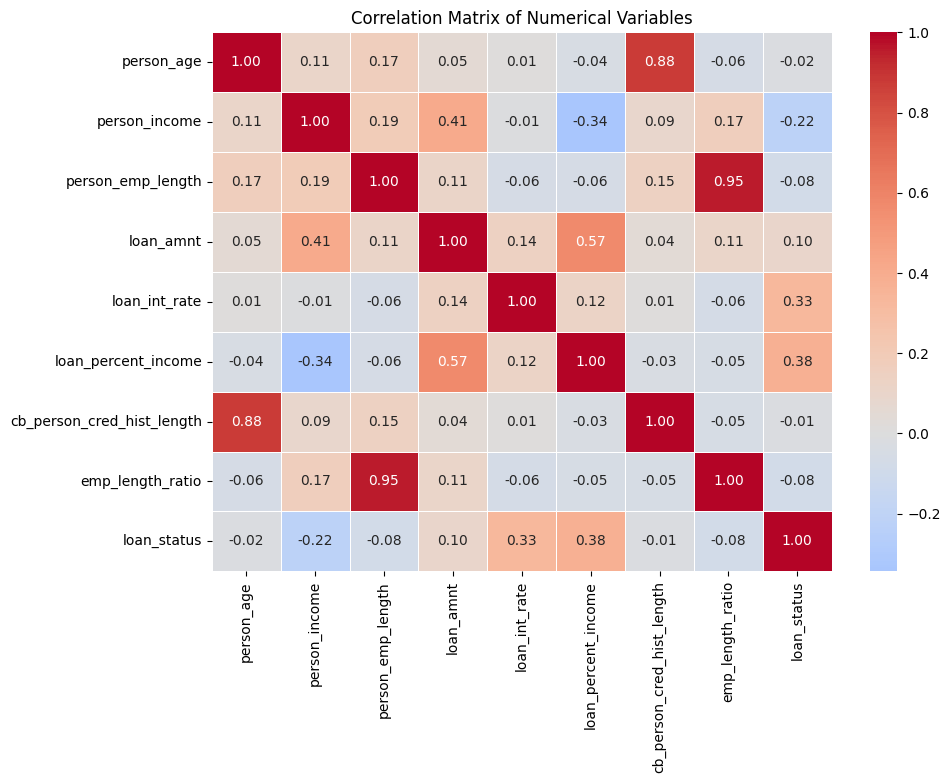

In [27]:
correlation_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'emp_length_ratio',
    'loan_status'
]

corr_matrix = eda_df[correlation_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### Correlation Insights

The correlation matrix highlights several important relationships among the numerical variables:

* **Loan Percent Income and Loan Status:** `loan_percent_income` has the strongest positive correlation with loan default among the numerical variables (**0.380**). This indicates that borrowers with a higher loan burden relative to their income tend to have a higher likelihood of default.

* **Loan Interest Rate and Loan Status:** `loan_int_rate` has a positive correlation of **0.334** with loan default, suggesting that higher interest rates are associated with higher default risk.

* **Income and Loan Status:** `person_income` has a negative correlation of **-0.221** with loan default, indicating that higher-income borrowers tend to have lower default risk.

* **Loan Amount and Loan Status:** `loan_amnt` has a relatively weak positive correlation of **0.108** with default, suggesting that loan amount alone has a limited linear relationship with the target.

* **Employment Length and Engineered Feature:** `person_emp_length` has a correlation of **-0.086** with loan status. The engineered `emp_length_ratio` has the same correlation (**-0.086**), suggesting that it may not provide additional linear predictive signal beyond the original employment-length feature. However, correlation alone cannot determine its predictive value, so its contribution should be evaluated later using model-based feature importance.

* **Age and Credit History:** `person_age` has a very weak negative correlation with loan status (**-0.019**), while `cb_person_cred_hist_length` has an even weaker correlation (**-0.015**). This indicates that these variables have limited individual linear relationships with default.

* **Loan Amount and Loan Percent Income:** These variables show a positive relationship because larger loans can represent a larger proportion of a borrower's income, although the strength of this relationship should be interpreted alongside income.

* **Age and Credit History Length:** A positive relationship is expected between borrower age and credit history length because older borrowers generally have had more time to build their credit history.

* **Loan Interest Rate and Loan Grade:** The analysis later in the notebook confirms a clear relationship between loan grade and interest rate. The mean interest rate increases from approximately **7.3% for Grade A to 20.2% for Grade G**, indicating that higher-risk loan grades are associated with higher interest rates.

Overall, the correlation analysis identifies several useful linear relationships, particularly for loan burden, interest rate, and income. However, correlation alone does not capture nonlinear relationships or interactions between variables, so the machine learning models will provide a more complete assessment of predictive performance.


##Relationship

 **Loan Grade vs Default Rate**

In [28]:
default_rate_grade = (
    eda_df.groupby('loan_grade')['loan_status']
      .mean()
      .reset_index(name='default_rate')
)

default_rate_grade['default_rate'] *= 100

default_rate_grade

,loan_grade,default_rate
0,A,10.014055
1,B,16.529126
2,C,20.298450
3,D,59.004494
4,E,63.989637
5,F,70.408163
6,G,98.148148


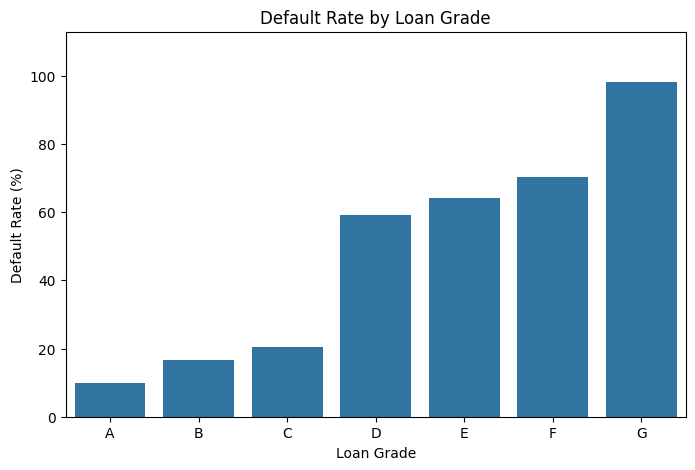

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=default_rate_grade,
    x='loan_grade',
    y='default_rate'
)

plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate (%)')
plt.ylim(0, default_rate_grade['default_rate'].max() * 1.15)

plt.show()

### Loan Grade and Default Risk

Loan grade shows a clear relationship with default risk. The default rate varies across the different loan grades, indicating that borrowers assigned to different risk categories do not have the same likelihood of default.

This relationship is particularly relevant to the problem statement because loan grade is designed to summarize the risk characteristics of a loan applicant. Therefore, it is expected to be an important predictor of loan default.

The variable is treated as an ordinal feature during preprocessing because the grades follow a natural ordered sequence from A to G.


**Loan Intent vs Default Rate**

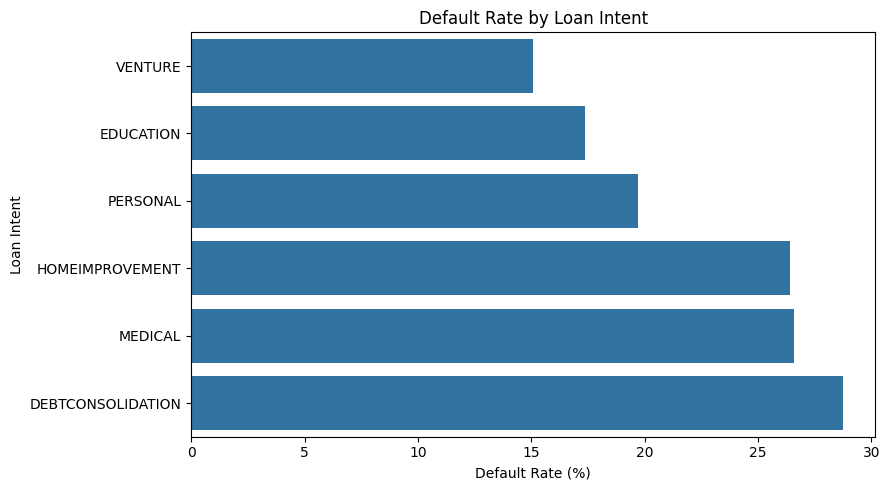

In [30]:
default_rate_intent = (
    eda_df.groupby('loan_intent')['loan_status']
      .mean()
      .reset_index(name='default_rate')
)

default_rate_intent['default_rate'] *= 100

default_rate_intent = default_rate_intent.sort_values(
    'default_rate',
    ascending=True
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=default_rate_intent,
    y='loan_intent',
    x='default_rate'
)

plt.title('Default Rate by Loan Intent')
plt.xlabel('Default Rate (%)')
plt.ylabel('Loan Intent')

plt.tight_layout()
plt.show()

### Loan Intent and Default Risk

Default rates differ across loan purposes. This indicates that the purpose of borrowing may be associated with different levels of credit risk.

This relationship is relevant from a business perspective because lenders may consider the intended use of a loan when assessing the likelihood of repayment. The feature is therefore retained as a categorical predictor for the machine learning models.


**Home Ownership vs Default**

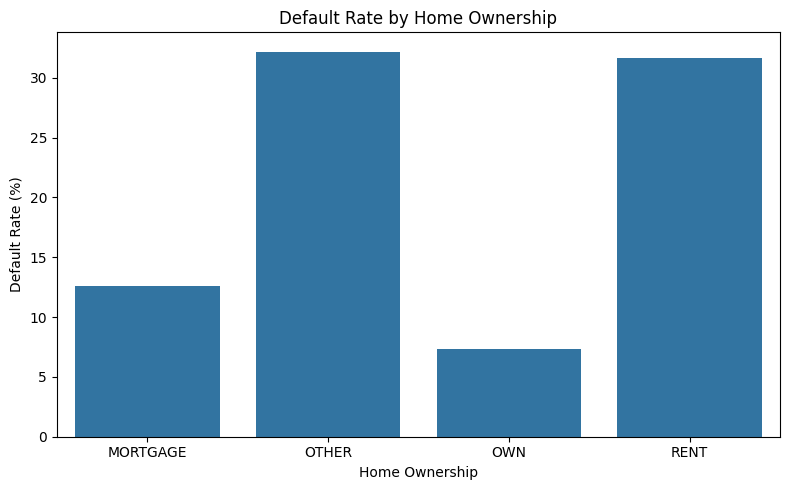

In [31]:
default_rate_home = (
    eda_df.groupby('person_home_ownership')['loan_status']
      .mean()
      .reset_index(name='default_rate')
)

default_rate_home['default_rate'] *= 100

plt.figure(figsize=(8, 5))

sns.barplot(
    data=default_rate_home,
    x='person_home_ownership',
    y='default_rate'
)

plt.title('Default Rate by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate (%)')

plt.tight_layout()
plt.show()

### Home Ownership and Default Risk

The default rate differs across home ownership categories. This suggests that housing status may contain information about a borrower's financial circumstances and therefore may contribute to distinguishing between lower- and higher-risk borrowers.

However, differences in group sizes should also be considered when interpreting these results, particularly for categories with relatively few observations.


**Loan-to-Income Ratio vs Default**

In [32]:
df_eda = eda_df.copy()

df_eda['loan_burden_group'] = pd.cut(
    df_eda['loan_percent_income'],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 1.0],
    labels=[
        '0–10%',
        '10–20%',
        '20–30%',
        '30–40%',
        '40–50%',
        '50–60%',
        '60–70%',
        '70%+'
    ],
    include_lowest=True
)

burden_default_rate = (
    df_eda.groupby(
        'loan_burden_group',
        observed=False
    )['loan_status']
    .mean()
    .mul(100)
    .reset_index(name='default_rate')
)

burden_default_rate

,loan_burden_group,default_rate
0,0–10%,11.798769
1,10–20%,15.180246
2,20–30%,21.908412
3,30–40%,68.081181
4,40–50%,72.916667
5,50–60%,77.852349
6,60–70%,83.333333
7,70%+,77.777778


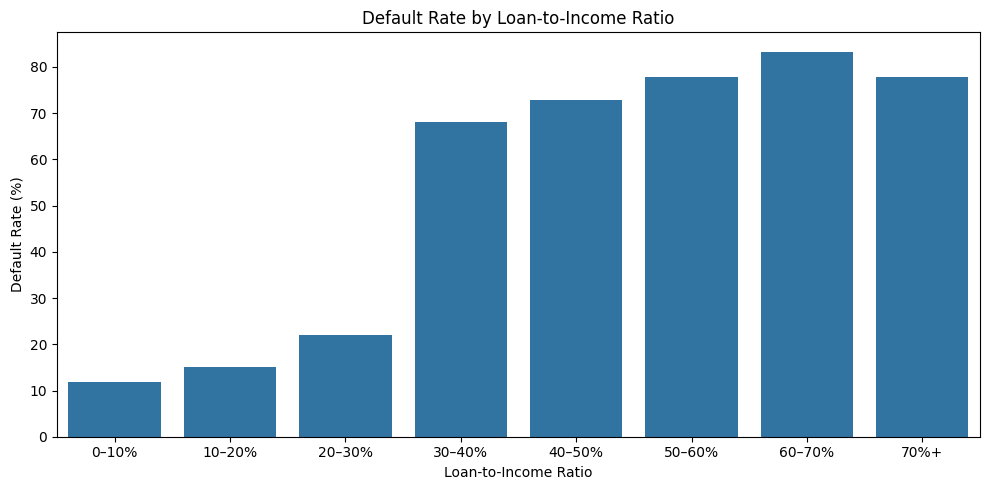

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=burden_default_rate,
    x='loan_burden_group',
    y='default_rate'
)

plt.title('Default Rate by Loan-to-Income Ratio')
plt.xlabel('Loan-to-Income Ratio')
plt.ylabel('Default Rate (%)')

plt.tight_layout()
plt.show()

### Loan Burden and Default Risk

The default rate varies across loan-to-income ratio groups. In general, higher loan burdens are associated with different levels of default risk, indicating that the proportion of income required to support a loan is relevant to credit risk assessment.

This relationship is particularly important from a business perspective because borrowers with higher loan burdens may have less financial capacity to meet their repayment obligations.


**Income vs Default**

In [34]:
df_eda['income_group'] = pd.qcut(
    df_eda['person_income'],
    q=5,
    duplicates='drop'
)

income_default_rate = (
    df_eda.groupby('income_group', observed=False)['loan_status']
    .mean()
    .mul(100)
    .reset_index(name='default_rate')
)

income_default_rate

,income_group,default_rate
0,"(4079.999, 35000.0]",43.274521
1,"(35000.0, 48500.0]",23.160601
2,"(48500.0, 63000.0]",19.211075
3,"(63000.0, 85000.0]",13.979552
4,"(85000.0, 300000.0]",9.397543


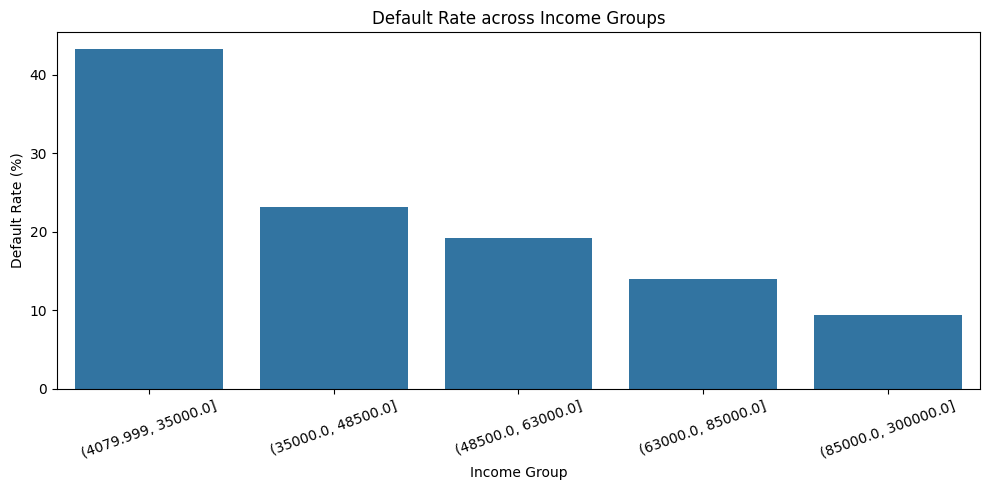

In [35]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=income_default_rate,
    x='income_group',
    y='default_rate'
)

plt.title('Default Rate across Income Groups')
plt.xlabel('Income Group')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

**Insight:** Default rates vary across borrower income groups, indicating that income level may contain useful information about repayment risk. However, income alone does not determine default, which supports considering multiple borrower and loan characteristics together.


**Loan Interest Rate vs Loan Grade**

In [36]:
grade_interest = (
    eda_df.groupby('loan_grade')['loan_int_rate']
      .mean()
      .reset_index()
)

grade_interest

,loan_grade,loan_int_rate
0,A,7.336845
1,B,10.990578
2,C,13.474072
3,D,15.369599
4,E,16.993557
5,F,18.628314
6,G,20.273529


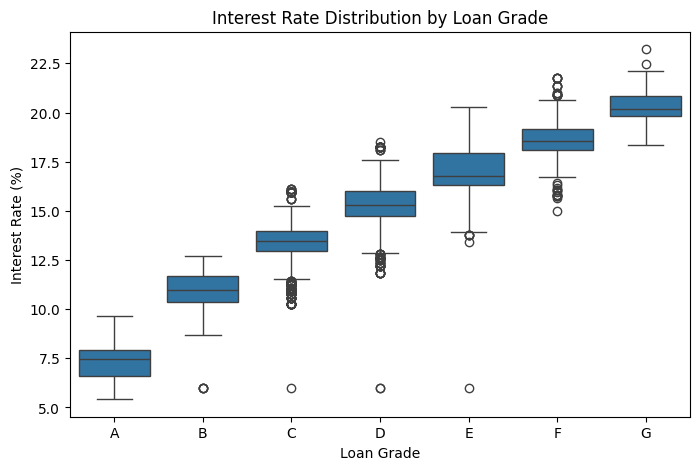

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=eda_df,
    x='loan_grade',
    y='loan_int_rate',
    order=['A', 'B', 'C', 'D', 'E', 'F', 'G']
)

plt.title('Interest Rate Distribution by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Interest Rate (%)')

plt.show()

### Loan Grade and Interest Rate

Loan interest rates show a clear increasing pattern across loan grades. The mean interest rate rises from approximately **7.3% for Grade A to 20.2% for Grade G**, indicating that higher-risk loan grades are associated with higher interest rates.

This relationship is important when interpreting the model because loan grade and interest rate may contain overlapping information about borrower or loan risk. Therefore, their relationship should be considered when interpreting model coefficients, particularly for linear models such as Logistic Regression.



**Correlation specifically with Target**

In [38]:
target_correlations = (
    corr_matrix['loan_status']
    .drop('loan_status')
    .sort_values(key=abs, ascending=False)
    .to_frame(name='correlation_with_loan_status')
)

target_correlations.round(3)

,correlation_with_loan_status
loan_percent_income,0.378
loan_int_rate,0.333
person_income,-0.222
loan_amnt,0.103
person_emp_length,-0.084
emp_length_ratio,-0.084
person_age,-0.020
cb_person_cred_hist_length,-0.014


### Relationship with the Target Variable

The correlation analysis provides an initial indication of which numerical variables have stronger linear associations with loan default.

However, correlation values should not be interpreted as measures of overall feature importance. A variable can have a relatively weak linear correlation with the target while still being useful to a machine learning model through nonlinear relationships or interactions with other variables.

Therefore, the correlation analysis is used as an exploratory tool, while final feature importance will be evaluated through the trained machine learning models.


# Data Transformation Piplines

### Rationale for Data Transformation:
To prepare the data for modeling, robust preprocessing pipelines were built:
1. **Handling Missing Values:** `SimpleImputer` with `strategy='median'` was used for numerical features to avoid the influence of extreme outliers. For categorical features, `most_frequent` was used. `add_indicator=True` was applied to flag missingness as a potential predictive pattern.
2. **Categorical Encoding:** 
   - `OrdinalEncoder` was applied to `loan_grade` because it has a natural internal ranking (A is better than B, etc.).
   - `OneHotEncoder` was applied to nominal features (`person_home_ownership`, `loan_intent`, `cb_person_default_on_file`) to convert them into a machine-readable binary format.
3. **Scaling:** `StandardScaler` was used to standardize numerical features. This is crucial for distance-based algorithms like Logistic Regression. Tree-based models (Random Forest, XGBoost) will receive the unscaled version to maintain their original distribution.

In [39]:
numeric_scaled = Pipeline([
    ('imputer', SimpleImputer(strategy='median',add_indicator=True)),
    ('scaler', StandardScaler())
])

In [40]:
numeric_unscaled = Pipeline([
    ('imputer', SimpleImputer(strategy='median',add_indicator=True))
])

In [41]:
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['A', 'B', 'C', 'D', 'E', 'F', 'G']]
    ))
])

In [42]:
onehot_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

In [43]:
preprocessor_scaled = ColumnTransformer([
    ('num', numeric_scaled, numerical_features),
    ('grade', ordinal_pipeline, ['loan_grade']),
    ('cat', onehot_pipeline, [
        'person_home_ownership',
        'loan_intent',
        'cb_person_default_on_file'
    ])
])

In [44]:
preprocessor_unscaled = ColumnTransformer([
    ('num', numeric_unscaled, numerical_features),
    ('grade', ordinal_pipeline, ['loan_grade']),
    ('cat', onehot_pipeline, [
        'person_home_ownership',
        'loan_intent',
        'cb_person_default_on_file'
    ])
])

In [45]:
X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_test_scaled = preprocessor_scaled.transform(X_test)

In [46]:
X_train_unscaled = preprocessor_unscaled.fit_transform(X_train)
X_test_unscaled = preprocessor_unscaled.transform(X_test)

##  Machine Learning Model & Evaluation

### Problem Classification
This is a **Binary Classification** problem. The objective is to predict whether a borrower will default on a loan (`loan_status` = 1) or fully repay it (`loan_status` = 0) based on their personal, financial, and loan-related features.

### Model Selection
We will train and evaluate three different algorithms to find the best performing one:
1. **Logistic Regression:** Serves as a strong baseline model. It requires scaled data because it is sensitive to the magnitude of features.
2. **Random Forest Classifier:** A powerful ensemble tree-based model that captures non-linear relationships well and does not require feature scaling.
3. **XGBoost Classifier:** An advanced gradient boosting algorithm known for its high performance and speed on tabular datasets. It also does not require scaled features.

In [47]:
def evaluate_model(
    model_name,
    model,
    X_test_data,
    y_test_data
):
    
    y_pred = model.predict(X_test_data)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_data)[:, 1]
    else:
        y_prob = None
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test_data,
            y_pred
        ),
        "Precision": precision_score(
            y_test_data,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_data,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test_data,
            y_pred,
            zero_division=0
        )
    }
    
    if y_prob is not None:
        metrics["ROC-AUC"] = roc_auc_score(
            y_test_data,
            y_prob
        )
        
        metrics["PR-AUC"] = average_precision_score(
            y_test_data,
            y_prob
        )
    else:
        metrics["ROC-AUC"] = np.nan
        metrics["PR-AUC"] = np.nan
    
    print(f"\n{'=' * 60}")
    print(model_name)
    print(f"{'=' * 60}")
    
    print("\nClassification Report:")
    print(
        classification_report(
            y_test_data,
            y_pred,
            zero_division=0
        )
    )
    
    cm = confusion_matrix(
        y_test_data,
        y_pred
    )
    
    print("Confusion Matrix:")
    print(cm)
    
    return metrics, y_pred, y_prob

In [48]:
baseline_models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        n_jobs=-1
    ),
    
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [49]:
baseline_results = []

trained_baseline_models = {}

baseline_probabilities = {}

baseline_predictions = {}

for name, model in baseline_models.items():
    
    print(f"\nTraining {name}...")
    
    if name == "Logistic Regression":
        X_train_model = X_train_scaled
        X_test_model = X_test_scaled
    else:
        X_train_model = X_train_unscaled
        X_test_model = X_test_unscaled
    
    model.fit(
        X_train_model,
        y_train
    )
    
    trained_baseline_models[name] = model
    
    metrics, y_pred, y_prob = evaluate_model(
        name,
        model,
        X_test_model,
        y_test
    )
    
    baseline_results.append(metrics)
    
    baseline_predictions[name] = y_pred
    
    baseline_probabilities[name] = y_prob


Training Logistic Regression...

Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      5063
           1       0.76      0.50      0.60      1418

    accuracy                           0.86      6481
   macro avg       0.82      0.73      0.76      6481
weighted avg       0.85      0.86      0.84      6481

Confusion Matrix:
[[4847  216]
 [ 716  702]]

Training Random Forest...

Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5063
           1       0.98      0.73      0.83      1418

    accuracy                           0.94      6481
   macro avg       0.95      0.86      0.90      6481
weighted avg       0.94      0.94      0.93      6481

Confusion Matrix:
[[5039   24]
 [ 389 1029]]

Training XGBoost...

XGBoost

Classification Report:
              precision    recall  f1-score   support

   

In [50]:
baseline_result_df = (
    pd.DataFrame(baseline_results)
    .sort_values(
        by="Recall",
        ascending=False
    )
    .reset_index(drop=True)
)

baseline_result_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost,0.938127,0.954424,0.753173,0.841939,0.951454,0.910141
1,Random Forest,0.936275,0.977208,0.725670,0.832861,0.929777,0.885043
2,Logistic Regression,0.856195,0.764706,0.495063,0.601027,0.868984,0.706997


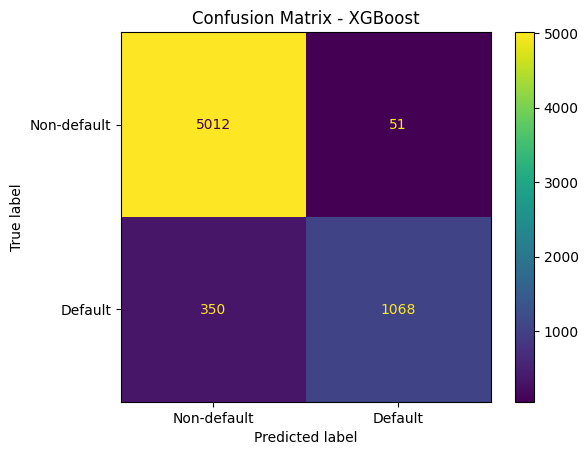

In [51]:
best_baseline_name = (
    baseline_result_df.iloc[0]["Model"]
)

best_baseline_pred = (
    baseline_predictions[best_baseline_name]
)

cm = confusion_matrix(
    y_test,
    best_baseline_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-default", "Default"]
)

disp.plot()

plt.title(
    f"Confusion Matrix - {best_baseline_name}"
)

plt.show()

In [52]:
weighted_models = {

    "Logistic Regression - Balanced": LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ),

    "Random Forest - Balanced": RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_estimators=200,
        n_jobs=-1
    ),

    "XGBoost - Weighted": XGBClassifier(
        scale_pos_weight=(
            y_train.value_counts()[0] /
            y_train.value_counts()[1]
        ),
        random_state=42,
        eval_metric="logloss"
    )
}

In [53]:
weighted_results = []
trained_weighted_models = {}
weighted_predictions = {}
weighted_probabilities = {}

for name, model in weighted_models.items():

    print(f"\nTraining {name}...")

    # Logistic Regression needs scaled data
    if "Logistic Regression" in name:
        X_train_model = X_train_scaled
        X_test_model = X_test_scaled

    # Tree-based models don't need scaling
    else:
        X_train_model = X_train_unscaled
        X_test_model = X_test_unscaled

    # Train WITHOUT SMOTE
    model.fit(
        X_train_model,
        y_train
    )

    trained_weighted_models[name] = model

    metrics, y_pred, y_prob = evaluate_model(
        name,
        model,
        X_test_model,
        y_test
    )

    weighted_results.append(metrics)

    weighted_predictions[name] = y_pred
    weighted_probabilities[name] = y_prob


Training Logistic Regression - Balanced...

Logistic Regression - Balanced

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.86      5063
           1       0.53      0.78      0.63      1418

    accuracy                           0.80      6481
   macro avg       0.73      0.79      0.75      6481
weighted avg       0.84      0.80      0.81      6481

Confusion Matrix:
[[4080  983]
 [ 312 1106]]

Training Random Forest - Balanced...

Random Forest - Balanced

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5063
           1       0.98      0.72      0.83      1418

    accuracy                           0.94      6481
   macro avg       0.96      0.86      0.90      6481
weighted avg       0.94      0.94      0.93      6481

Confusion Matrix:
[[5045   18]
 [ 395 1023]]

Training XGBoost - Weighted...

XGBoost - Weighted

Classification 

In [54]:
weighted_result_df = (
    pd.DataFrame(weighted_results)
    .sort_values(by="Recall", ascending=False)
    .reset_index(drop=True)
)

weighted_result_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost - Weighted,0.924394,0.842688,0.804654,0.823232,0.950562,0.910454
1,Logistic Regression - Balanced,0.800185,0.529440,0.779972,0.630739,0.869982,0.702891
2,Random Forest - Balanced,0.936275,0.982709,0.721439,0.832046,0.938008,0.893374


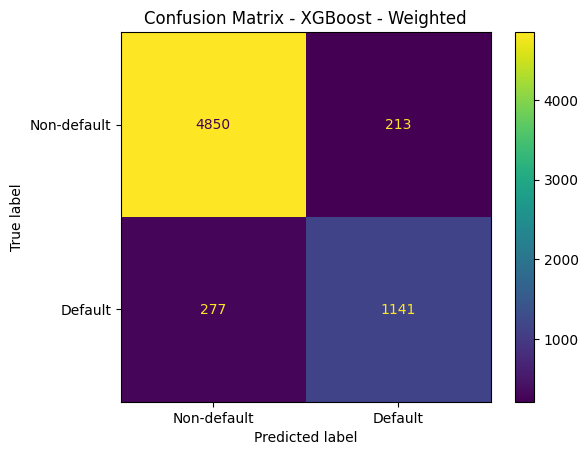

In [55]:
best_weighted_name = (
weighted_result_df.iloc[0]["Model"]
)

best_weighted_pred = (
    weighted_predictions[best_weighted_name]
)

cm = confusion_matrix(
    y_test,
    best_weighted_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-default", "Default"]
)

disp.plot()

plt.title(
    f"Confusion Matrix - {best_weighted_name}"
)

plt.show()

In [56]:
comparison_before_smote = pd.concat(
    [
        baseline_result_df,
        weighted_result_df
    ],
    ignore_index=True
)

comparison_before_smote.sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost - Weighted,0.924394,0.842688,0.804654,0.823232,0.950562,0.910454
1,Logistic Regression - Balanced,0.800185,0.529440,0.779972,0.630739,0.869982,0.702891
2,XGBoost,0.938127,0.954424,0.753173,0.841939,0.951454,0.910141
3,Random Forest,0.936275,0.977208,0.725670,0.832861,0.929777,0.885043
4,Random Forest - Balanced,0.936275,0.982709,0.721439,0.832046,0.938008,0.893374
5,Logistic Regression,0.856195,0.764706,0.495063,0.601027,0.868984,0.706997


In [57]:
smote = SMOTE(random_state=42)

smote_scaled = SMOTE(random_state=42)
X_train_scaled_smote, y_train_smote = smote_scaled.fit_resample(
    X_train_scaled,
    y_train
)

smote_unscaled = SMOTE(random_state=42)
X_train_unscaled_smote, y_train_unscaled_smote = smote_unscaled.fit_resample(
    X_train_unscaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

  File "C:\Users\esraa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                  

Before SMOTE:
loan_status
0    20250
1     5670
Name: count, dtype: int64

After SMOTE:
loan_status
0    20250
1    20250
Name: count, dtype: int64


In [58]:
smote_models = {

    "Logistic Regression - SMOTE": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Random Forest - SMOTE": RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        n_jobs=-1
    ),

    "XGBoost - SMOTE": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [59]:
smote_results = []
trained_smote_models = {}
smote_predictions = {}
smote_probabilities = {}

for name, model in smote_models.items():

    print(f"\nTraining {name}...")

    if "Logistic Regression" in name:

        X_train_model = X_train_scaled_smote
        X_test_model = X_test_scaled

    else:

        X_train_model = X_train_unscaled_smote
        X_test_model = X_test_unscaled

    model.fit(
        X_train_model,
        y_train_smote
    )

    trained_smote_models[name] = model

    metrics, y_pred, y_prob = evaluate_model(
        name,
        model,
        X_test_model,
        y_test
    )

    smote_results.append(metrics)

    smote_predictions[name] = y_pred
    smote_probabilities[name] = y_prob


Training Logistic Regression - SMOTE...

Logistic Regression - SMOTE

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      5063
           1       0.54      0.78      0.63      1418

    accuracy                           0.80      6481
   macro avg       0.73      0.79      0.75      6481
weighted avg       0.84      0.80      0.82      6481

Confusion Matrix:
[[4106  957]
 [ 316 1102]]

Training Random Forest - SMOTE...

Random Forest - SMOTE

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5063
           1       0.97      0.73      0.83      1418

    accuracy                           0.94      6481
   macro avg       0.95      0.86      0.90      6481
weighted avg       0.94      0.94      0.93      6481

Confusion Matrix:
[[5035   28]
 [ 387 1031]]

Training XGBoost - SMOTE...

XGBoost - SMOTE

Classification Report:
          

In [60]:
smote_result_df = (
    pd.DataFrame(smote_results)
    .sort_values(by="Recall", ascending=False)
    .reset_index(drop=True)
)

smote_result_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression - SMOTE,0.803580,0.535211,0.777151,0.633880,0.869168,0.702293
1,XGBoost - SMOTE,0.937664,0.958409,0.747532,0.839937,0.949808,0.909694
2,Random Forest - SMOTE,0.935967,0.973560,0.727080,0.832459,0.930820,0.885318


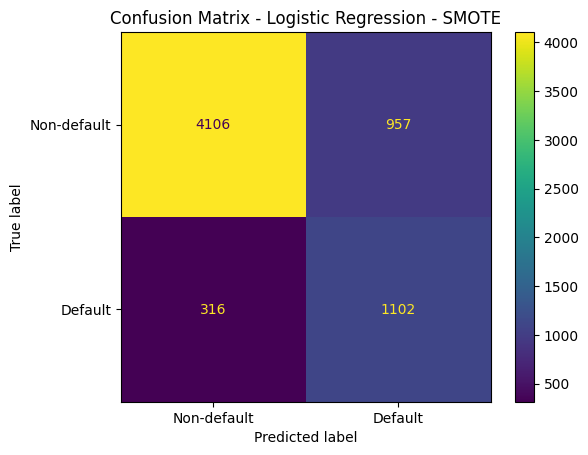

In [61]:
best_smote_name = (
    smote_result_df.iloc[0]["Model"]
)

best_smote_pred = (
    smote_predictions[best_smote_name]
)

cm = confusion_matrix(
    y_test,
    best_smote_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-default", "Default"]
)

disp.plot()

plt.title(
    f"Confusion Matrix - {best_smote_name}"
)

plt.show()

In [62]:
comparison_after_smote = pd.concat(
    [
        baseline_result_df,
        weighted_result_df,
        smote_result_df
    ],
    ignore_index=True
)

comparison_after_smote.sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost - Weighted,0.924394,0.842688,0.804654,0.823232,0.950562,0.910454
1,Logistic Regression - Balanced,0.800185,0.529440,0.779972,0.630739,0.869982,0.702891
2,Logistic Regression - SMOTE,0.803580,0.535211,0.777151,0.633880,0.869168,0.702293
3,XGBoost,0.938127,0.954424,0.753173,0.841939,0.951454,0.910141
4,XGBoost - SMOTE,0.937664,0.958409,0.747532,0.839937,0.949808,0.909694
5,Random Forest - SMOTE,0.935967,0.973560,0.727080,0.832459,0.930820,0.885318
6,Random Forest,0.936275,0.977208,0.725670,0.832861,0.929777,0.885043
7,Random Forest - Balanced,0.936275,0.982709,0.721439,0.832046,0.938008,0.893374
8,Logistic Regression,0.856195,0.764706,0.495063,0.601027,0.868984,0.706997


In [63]:
lr_param_dist = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

rf_param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

xgb_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.5]
}

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [64]:
tuning_configs = {

    # Best Recall version = Weighted
    "Logistic Regression": {
        "estimator": LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        ),
        "param_distributions": lr_param_dist,

        "X_train": X_train_scaled,
        "y_train": y_train,

        "X_test": X_test_scaled,

        "n_iter": 20
    },

    # Best Recall version = SMOTE
    "Random Forest": {
        "estimator": RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ),
        "param_distributions": rf_param_dist,

        "X_train": X_train_unscaled_smote,
        "y_train": y_train_unscaled_smote,

        "X_test": X_test_unscaled,

        "n_iter": 30
    },

    # Best Recall version = Weighted
    "XGBoost": {
        "estimator": XGBClassifier(
            scale_pos_weight=(
                y_train.value_counts()[0] /
                y_train.value_counts()[1]
            ),
            random_state=42,
            eval_metric="logloss"
        ),
        "param_distributions": xgb_param_dist,

        "X_train": X_train_unscaled,
        "y_train": y_train,

        "X_test": X_test_unscaled,

        "n_iter": 30
    }
}

In [65]:
from sklearn.model_selection import RandomizedSearchCV

tuned_results = []
trained_tuned_models = {}
tuned_predictions = {}
tuned_probabilities = {}
best_params = {}

for name, config in tuning_configs.items():

    print(f"\n{'='*60}")
    print(f"Tuning {name}...")
    print(f"{'='*60}")

    search = RandomizedSearchCV(
        estimator=config["estimator"],
        param_distributions=config["param_distributions"],
        n_iter=config["n_iter"],
        scoring="recall",          
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    search.fit(
        config["X_train"],
        config["y_train"]
    )

    # Best model
    best_model = search.best_estimator_

    trained_tuned_models[name] = best_model
    best_params[name] = search.best_params_

    print(f"\nBest Recall (CV): {search.best_score_:.4f}")
    print("Best Parameters:")
    print(search.best_params_)

    # Evaluate on untouched test set
    metrics, y_pred, y_prob = evaluate_model(
        f"{name} - Tuned",
        best_model,
        config["X_test"],
        y_test
    )

    tuned_results.append(metrics)

    tuned_predictions[name] = y_pred
    tuned_probabilities[name] = y_prob


Tuning Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Recall (CV): 0.8074
Best Parameters:
{'solver': 'liblinear', 'penalty': 'l2', 'C': 0.001}

Logistic Regression - Tuned

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84      5063
           1       0.48      0.81      0.61      1418

    accuracy                           0.77      6481
   macro avg       0.71      0.78      0.72      6481
weighted avg       0.84      0.77      0.79      6481

Confusion Matrix:
[[3835 1228]
 [ 269 1149]]

Tuning Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Recall (CV): 0.9196
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Random Forest - Tuned

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96

In [66]:
tuned_result_df = (
    pd.DataFrame(tuned_results)
    .sort_values(
        by="Recall",
        ascending=False
    )
    .reset_index(drop=True)
)

tuned_result_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost - Tuned,0.918222,0.808762,0.820169,0.814426,0.951123,0.908852
1,Logistic Regression - Tuned,0.769017,0.483382,0.810296,0.605534,0.859550,0.680671
2,Random Forest - Tuned,0.936892,0.978199,0.727786,0.834614,0.932822,0.888945


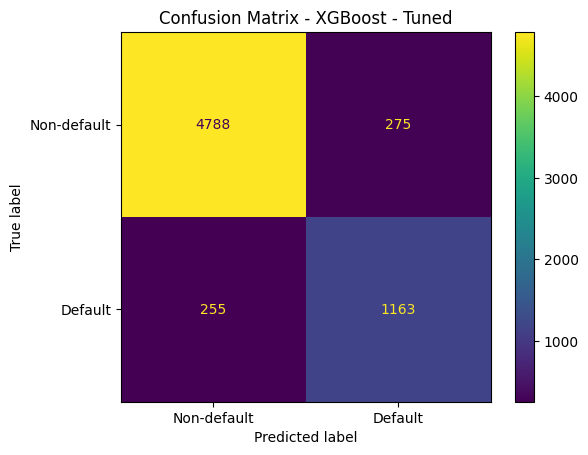

In [67]:
best_tuned_name = tuned_result_df.iloc[0]["Model"]

original_name = best_tuned_name.replace(" - Tuned", "")

best_tuned_pred = tuned_predictions[original_name]

cm = confusion_matrix(
    y_test,
    best_tuned_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-default", "Default"]
)

disp.plot()

plt.title(
    f"Confusion Matrix - {best_tuned_name}"
)

plt.show()

In [68]:
final_comparison = pd.concat(
    [
        baseline_result_df,
        weighted_result_df,
        smote_result_df,
        tuned_result_df
    ],
    ignore_index=True
).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost - Tuned,0.918222,0.808762,0.820169,0.814426,0.951123,0.908852
1,Logistic Regression - Tuned,0.769017,0.483382,0.810296,0.605534,0.859550,0.680671
2,XGBoost - Weighted,0.924394,0.842688,0.804654,0.823232,0.950562,0.910454
3,Logistic Regression - Balanced,0.800185,0.529440,0.779972,0.630739,0.869982,0.702891
4,Logistic Regression - SMOTE,0.803580,0.535211,0.777151,0.633880,0.869168,0.702293
5,XGBoost,0.938127,0.954424,0.753173,0.841939,0.951454,0.910141
6,XGBoost - SMOTE,0.937664,0.958409,0.747532,0.839937,0.949808,0.909694
7,Random Forest - Tuned,0.936892,0.978199,0.727786,0.834614,0.932822,0.888945
8,Random Forest - SMOTE,0.935967,0.973560,0.727080,0.832459,0.930820,0.885318
9,Random Forest,0.936275,0.977208,0.725670,0.832861,0.929777,0.885043


In [69]:
def find_best_threshold(
    y_true,
    y_prob,
    metric="recall",
    min_precision=0.50
):
    precisions, recalls, thresholds = precision_recall_curve(
        y_true,
        y_prob
    )

    # Make lengths equal to thresholds
    precisions = precisions[:-1]
    recalls = recalls[:-1]

    f1_scores = (
        2 * (precisions * recalls) /
        (precisions + recalls + 1e-12)
    )

    if metric == "recall":

        # Keep only thresholds with acceptable precision
        valid_indices = np.where(
            precisions >= min_precision
        )[0]

        if len(valid_indices) == 0:
            raise ValueError(
                f"No threshold satisfies minimum precision "
                f"of {min_precision}"
            )

        # Maximize Recall
        best_idx = valid_indices[
            np.argmax(recalls[valid_indices])
        ]

        best_score = recalls[best_idx]

    elif metric == "f1":

        best_idx = np.argmax(f1_scores)
        best_score = f1_scores[best_idx]

    else:
        raise ValueError(
            "metric must be 'recall' or 'f1'"
        )

    return thresholds[best_idx], best_score

In [70]:
def evaluate_with_threshold(
    model_name,
    y_true,
    y_prob,
    threshold
):

    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Model": model_name,
        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1 Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            y_prob
        ),

        "PR-AUC": average_precision_score(
            y_true,
            y_prob
        )
    }

    return metrics, y_pred

In [71]:
all_probabilities = {}

all_probabilities.update(
    baseline_probabilities
)

all_probabilities.update(
    weighted_probabilities
)

all_probabilities.update(
    smote_probabilities
)

all_probabilities.update(
    tuned_probabilities
)

print("Number of models:", len(all_probabilities))

Number of models: 9


In [72]:
threshold_results = []

threshold_predictions = {}

optimal_thresholds = {}

for name, y_prob in all_probabilities.items():

    if y_prob is None:
        continue

    try:

        best_threshold, best_recall = find_best_threshold(
            y_test,
            y_prob,
            metric="recall",
            min_precision=0.50
        )

        optimal_thresholds[name] = best_threshold

        threshold_name = f"{name} - Threshold Tuned"

        metrics, y_pred = evaluate_with_threshold(
            threshold_name,
            y_test,
            y_prob,
            best_threshold
        )

        threshold_results.append(metrics)

        threshold_predictions[threshold_name] = y_pred

        print(
            f"{name}: "
            f"Threshold = {best_threshold:.3f} | "
            f"Recall = {metrics['Recall']:.4f} | "
            f"Precision = {metrics['Precision']:.4f} | "
            f"F1 = {metrics['F1 Score']:.4f}"
        )

    except ValueError as e:

        print(f"{name}: {e}")

Logistic Regression: Threshold = 0.514 | Recall = 0.8018 | Precision = 0.5000 | F1 = 0.6159
Random Forest: Threshold = 0.132 | Recall = 0.8865 | Precision = 0.5000 | F1 = 0.6394
XGBoost: Threshold = 0.252 | Recall = 0.9309 | Precision = 0.5000 | F1 = 0.6506
Logistic Regression - Balanced: Threshold = 0.456 | Recall = 0.8145 | Precision = 0.5000 | F1 = 0.6196
Random Forest - Balanced: Threshold = 0.120 | Recall = 0.9055 | Precision = 0.5087 | F1 = 0.6514
XGBoost - Weighted: Threshold = 0.180 | Recall = 0.9316 | Precision = 0.5000 | F1 = 0.6507
Logistic Regression - SMOTE: Threshold = 0.454 | Recall = 0.8068 | Precision = 0.5000 | F1 = 0.6174
Random Forest - SMOTE: Threshold = 0.135 | Recall = 0.8872 | Precision = 0.5071 | F1 = 0.6453
XGBoost - SMOTE: Threshold = 0.076 | Recall = 0.9281 | Precision = 0.5000 | F1 = 0.6499


In [73]:
threshold_result_df = (
    pd.DataFrame(threshold_results)
    .sort_values(
        by="Recall",
        ascending=False
    )
    .reset_index(drop=True)
)

threshold_result_df

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost - Weighted - Threshold Tuned,0.180383,0.781207,0.500000,0.931594,0.650739,0.950562,0.910454
1,XGBoost - Threshold Tuned,0.252348,0.781207,0.500000,0.930889,0.650567,0.951123,0.908852
2,XGBoost - SMOTE - Threshold Tuned,0.076176,0.781207,0.500000,0.928068,0.649877,0.949808,0.909694
3,Random Forest - Balanced - Threshold Tuned,0.120000,0.787996,0.508716,0.905501,0.651446,0.938008,0.893374
4,Random Forest - SMOTE - Threshold Tuned,0.135000,0.786607,0.507054,0.887165,0.645294,0.930820,0.885318
5,Random Forest - Threshold Tuned,0.132310,0.781207,0.500000,0.886460,0.639369,0.932822,0.888945
6,Logistic Regression - Balanced - Threshold Tuned,0.455661,0.781207,0.500000,0.814528,0.619635,0.869982,0.702891
7,Logistic Regression - SMOTE - Threshold Tuned,0.453758,0.781207,0.500000,0.806770,0.617377,0.869168,0.702293
8,Logistic Regression - Threshold Tuned,0.514010,0.781207,0.500000,0.801834,0.615926,0.859550,0.680671


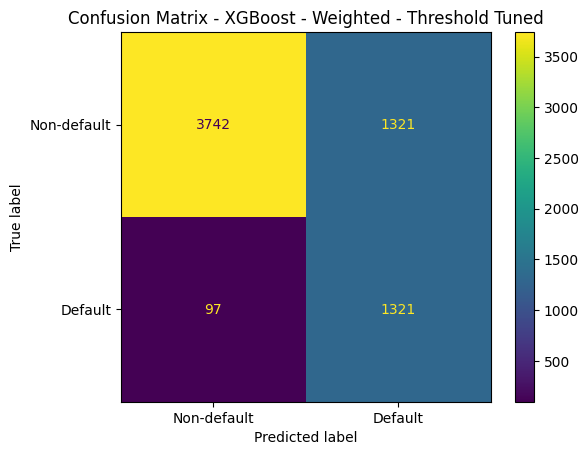

In [74]:
best_threshold_name = threshold_result_df.iloc[0]["Model"]

best_threshold_pred = threshold_predictions[best_threshold_name]

cm = confusion_matrix(
    y_test,
    best_threshold_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-default", "Default"]
)

disp.plot()

plt.title(
    f"Confusion Matrix - {best_threshold_name}"
)

plt.show()

In [75]:
final_comparison = pd.concat(
    [
        baseline_result_df,
        weighted_result_df,
        smote_result_df,
        tuned_result_df,
        threshold_result_df
    ],
    ignore_index=True
).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Threshold
0,XGBoost - Weighted - Threshold Tuned,0.781207,0.500000,0.931594,0.650739,0.950562,0.910454,0.180383
1,XGBoost - Threshold Tuned,0.781207,0.500000,0.930889,0.650567,0.951123,0.908852,0.252348
2,XGBoost - SMOTE - Threshold Tuned,0.781207,0.500000,0.928068,0.649877,0.949808,0.909694,0.076176
3,Random Forest - Balanced - Threshold Tuned,0.787996,0.508716,0.905501,0.651446,0.938008,0.893374,0.120000
4,Random Forest - SMOTE - Threshold Tuned,0.786607,0.507054,0.887165,0.645294,0.930820,0.885318,0.135000
5,Random Forest - Threshold Tuned,0.781207,0.500000,0.886460,0.639369,0.932822,0.888945,0.132310
6,XGBoost - Tuned,0.918222,0.808762,0.820169,0.814426,0.951123,0.908852,NaN
7,Logistic Regression - Balanced - Threshold Tuned,0.781207,0.500000,0.814528,0.619635,0.869982,0.702891,0.455661
8,Logistic Regression - Tuned,0.769017,0.483382,0.810296,0.605534,0.859550,0.680671,NaN
9,Logistic Regression - SMOTE - Threshold Tuned,0.781207,0.500000,0.806770,0.617377,0.869168,0.702293,0.453758


In [77]:
models = {
    "Logistic Regression - Weighted": weighted_models["Logistic Regression - Balanced"],
    "Logistic Regression - SMOTE": smote_models["Logistic Regression - SMOTE"],
    "XGBoost - Normal": baseline_models["XGBoost"],
    "XGBoost - Weighted": weighted_models["XGBoost - Weighted"],
    "XGBoost - SMOTE": smote_models["XGBoost - SMOTE"]
}

In [78]:
results = []

for model_name, model in models.items():

    if model_name.startswith("Logistic Regression"):
        X_eval = X_test_scaled

    else:
        X_eval = X_test_unscaled

    # Predictions
    y_pred = model.predict(X_eval)

    # Probabilities
    y_proba = model.predict_proba(X_eval)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, y_proba
        ),
        "PR-AUC": average_precision_score(
            y_test, y_proba
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression - Weighted,0.800185,0.529440,0.779972,0.630739,0.869982,0.702891
1,Logistic Regression - SMOTE,0.803580,0.535211,0.777151,0.633880,0.869168,0.702293
2,XGBoost - Normal,0.938127,0.954424,0.753173,0.841939,0.951454,0.910141
3,XGBoost - Weighted,0.924394,0.842688,0.804654,0.823232,0.950562,0.910454
4,XGBoost - SMOTE,0.937664,0.958409,0.747532,0.839937,0.949808,0.909694


In [83]:
# ============================================================
# SAVE DEPLOYMENT ARTIFACTS
# ============================================================

import joblib
import os

# Create models directory
os.makedirs("models", exist_ok=True)


# ============================================================
# 1. SAVE ALL 5 MODELS
# ============================================================

MODEL_FILENAMES = {
    "Logistic Regression - Weighted": "models/logistic_weighted.pkl",
    "Logistic Regression - SMOTE": "models/logistic_smote.pkl",
    "XGBoost - Normal": "models/xgboost_normal.pkl",
    "XGBoost - Weighted": "models/xgboost_weighted.pkl",
    "XGBoost - SMOTE": "models/xgboost_smote.pkl"
}

for model_name, filename in MODEL_FILENAMES.items():
    
    joblib.dump(
        models[model_name],
        filename
    )
    
    print(f"Saved: {filename}")


# ============================================================
# 2. SAVE BEST MODEL
# ============================================================

best_model_name = "XGBoost - Weighted"
best_model = models[best_model_name]

joblib.dump(
    best_model,
    "models/xgboost_weighted.pkl"
)

print("Best model saved: models/xgboost_weighted.pkl")


# ============================================================
# 3. SAVE THE PREPROCESSOR USED BY XGBOOST
# IMPORTANT:
# XGBoost was trained using X_train_unscaled
# Therefore we save preprocessor_unscaled
# ============================================================

joblib.dump(
    preprocessor_unscaled,
    "models/preprocessor_unscaled.pkl"
)

print("Saved: models/preprocessor_unscaled.pkl")


# ============================================================
# 4. SAVE INCOME THRESHOLD
# Used before preprocessing
# ============================================================

joblib.dump(
    income_threshold,
    "models/income_threshold.pkl"
)

print("Saved: models/income_threshold.pkl")


# ============================================================
# 5. SAVE MODEL METRICS
# ============================================================

results_df.to_csv(
    "model_metrics.csv",
    index=False
)

print("Saved: model_metrics.csv")


# ============================================================
# 6. VERIFY SAVED FILES
# ============================================================

print("\nSaved files:")

for file in os.listdir("models"):
    print("-", file)


print("\nDeployment artifacts saved successfully!")


Saved: models/logistic_weighted.pkl
Saved: models/logistic_smote.pkl
Saved: models/xgboost_normal.pkl
Saved: models/xgboost_weighted.pkl
Saved: models/xgboost_smote.pkl
Best model saved: models/xgboost_weighted.pkl
Saved: models/preprocessor_unscaled.pkl
Saved: models/income_threshold.pkl
Saved: model_metrics.csv

Saved files:
- income_threshold.pkl
- logistic_smote.pkl
- logistic_weighted.pkl
- preprocessor_unscaled.pkl
- xgboost_normal.pkl
- xgboost_smote.pkl
- xgboost_weighted.pkl

Deployment artifacts saved successfully!
